In [3]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from copy import copy
import scipy
import pynumdiff

os.environ["JULIA_PROJECT"] = ""
os.environ["PYTHON_JULIAPKG_USE_CACHE"] = "false"

from pysr import PySRRegressor
import pysindy
import pynumdiff
from scipy.signal import savgol_filter

2025-10-21 14:19:57,009 [INFO] 
Limited Total Variation Regularization Support Detected! 
---> CVXPY is not installed. 
---> Many Total Variation Methods require CVXPY including: 
---> velocity, acceleration, jerk, jerk_sliding, smooth_acceleration
---> Please install CVXPY to use these methods.
---> Recommended to also install MOSEK and obtain a MOSEK license.
You can still use: total_variation_regularization.iterative_velocity

2025-10-21 14:19:57,028 [INFO] 
Limited Linear Model Support Detected! 
---> PYCHEBFUN is not installed. 
---> Install pychebfun to use chebfun derivatives (https://github.com/pychebfun/pychebfun/) 
You can still use other methods 

2025-10-21 14:19:57,029 [INFO] 
Limited Linear Model Support Detected! 
---> CVXPY is not installed. 
---> Install CVXPY to use lineardiff derivatives 
You can still use other methods 



[juliapkg] Found dependencies: /home/oriolca/.local/lib/python3.10/site-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /home/oriolca/.local/lib/python3.10/site-packages/juliacall/juliapkg.json
[juliapkg] Found dependencies: /home/oriolca/.local/lib/python3.10/site-packages/pysr/juliapkg.json
[juliapkg] Locating Julia ^1.10.3
[juliapkg] Using Julia 1.12.0 at /home/oriolca/julia-1.12.0/bin/julia
[juliapkg] Using Julia project at /home/oriolca/.julia/environments/pyjuliapkg
[juliapkg] Writing Project.toml:
           | [deps]
           | PythonCall = "6099a3de-0909-46bc-b1f4-468b9a2dfc0d"
           | OpenSSL_jll = "458c3c95-2e84-50aa-8efc-19380b2a3a95"
           | SymbolicRegression = "8254be44-1295-4e6a-a16d-46603ac705cb"
           | Serialization = "9e88b42a-f829-5b0c-bbe9-9e923198166b"
           | 
           | [compat]
           | PythonCall = "=0.9.26"
           | OpenSSL_jll = "~3.0"
           | SymbolicRegression = "~1.11"
           | Serialization = "^1"
[

CalledProcessError: Command '['/home/oriolca/julia-1.12.0/bin/julia', '--project=/home/oriolca/.julia/environments/pyjuliapkg', '--startup-file=no', '-e', 'import Pkg\nPkg.Registry.update()\nPkg.add([\n  Pkg.PackageSpec(name="PythonCall", uuid="6099a3de-0909-46bc-b1f4-468b9a2dfc0d"),\n  Pkg.PackageSpec(name="OpenSSL_jll", uuid="458c3c95-2e84-50aa-8efc-19380b2a3a95"),\n  Pkg.PackageSpec(name="SymbolicRegression", uuid="8254be44-1295-4e6a-a16d-46603ac705cb"),\n  Pkg.PackageSpec(name="Serialization", uuid="9e88b42a-f829-5b0c-bbe9-9e923198166b"),\n])\nPkg.resolve()\nPkg.precompile()']' returned non-zero exit status 1.

0.01
[9.0069813  9.10373537 9.17907046 ... 9.80442904 9.80117321 9.80377265]
[ 8.32995401  8.22386937  8.12419689 ...  0.01887003 -0.05660676
 -0.14945704]


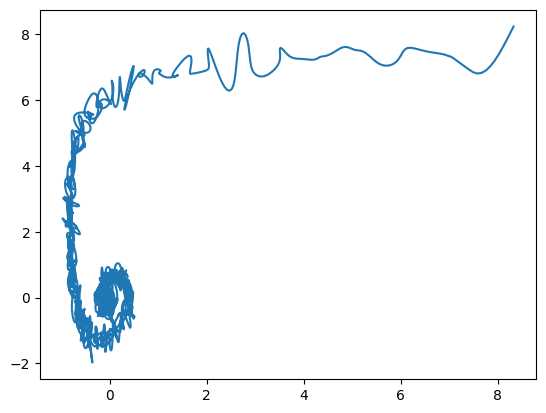

In [4]:
data = pd.read_csv('datasets/bact_res_SNR50.csv')

h=data.t.to_numpy()[1] - data.t.to_numpy()[0]
print(h)
print(data.x.to_numpy())
x_hat, dxdt_hat = pynumdiff.polydiff(data.x.to_numpy(), dt=h, params=[2,20,20])
print(dxdt_hat)
y_hat, dydt_hat = pynumdiff.polydiff(data.y.to_numpy(), dt=h, params=[2,20,20])

plt.plot(dxdt_hat,dydt_hat)

In [5]:
model = PySRRegressor(
    populations=8,                   # Fewer populations (parallel groups)
    population_size=30,              # 30 individuals per population
    ncycles_per_iteration=100,       # 100 generations between migrations
    niterations=1000,                 # Total 100 migrations → ~10,000 generations
    early_stop_condition="stop_if(loss, complexity) = loss < 1e-6 && complexity < 15",
    timeout_in_seconds=60 * 60 * 12,      # 1 hour wall-time limit
    maxsize=30,
    maxdepth=10,
    model_selection="best",   # or 'accuracy'
    binary_operators=["*", "+", "-", "/"],
    unary_operators=["square", "cube", "exp"],
    constraints={
        "/": (-1, 9),
        "square": 9,
        "cube": 9,
        "exp": 9,
    },
    # ^ Limit the complexity within each argument.
    # "inv": (-1, 9) states that the numerator has no constraint,
    # but the denominator has a max complexity of 9.
    # "exp": 9 simply states that `exp` can only have
    # an expression of complexity 9 as input.
    nested_constraints={
        "square": {"square": 1, "cube": 1, "exp": 0},
        "cube": {"square": 1, "cube": 1, "exp": 0},
        "exp": {"square": 1, "cube": 1, "exp": 0},
    }
    # ^ Define operator for SymPy as well
)

X = data[['x','y']]

model.fit(X, dxdt_hat)

p_x = model.predict(X)

print(model)

model.fit(X, dydt_hat)

p_y = model.predict(X)

print(model)

plt.scatter(p_x,p_y)

NameError: name 'PySRRegressor' is not defined

In [ ]:
n_models=1000
library_functions = [lambda x: x, lambda x: x * x, lambda x, y: x * y,
                     lambda x, y: x * x * y,lambda x, y: x * y * y,lambda x: x * x * x]
library_function_names = [lambda x: x,lambda x: x+x,lambda x, y: x+y,
                     lambda x, y: x+x+y,lambda x, y: x + y + y,lambda x: x + x + x]
feature_names = ['x','y']
ensemble_optimizer = pysindy.STLSQ(threshold=1e-2)

weak_lib = pysindy.WeakPDELibrary(
    library_functions=library_functions,
    function_names=library_function_names,
    include_bias=True,
    spatiotemporal_grid=data.t.to_numpy(),
    is_uniform=True,
    K=1000,
)

# SINDy initialization
model = pysindy.SINDy(
    feature_names=feature_names,
    feature_library=weak_lib,
    optimizer=ensemble_optimizer,
)
model.fit(
    X,
    ensemble=True,
    n_models=n_models,
    quiet=True
)
model.print()
print(model.coefficients())

pred = model.predict(X)

plt.scatter(pred[:,0],pred[:,1])

In [ ]:
n_models=1000
ensemble_optimizer = pysindy.STLSQ(threshold=1e-2)
poly_library = pysindy.PolynomialLibrary(degree=3, include_bias=True)
model = pysindy.SINDy(
    feature_names=['x','y'],
    feature_library=poly_library,
    optimizer=ensemble_optimizer,
)

model.fit(X, t=h, ensemble=True, n_models=n_models, quiet=True)

model.print()
print(model.coefficients())

pred = model.predict(X)

plt.scatter(pred[:,0],pred[:,1])